# About the Data

The descriptions of these features were referenced from the **Bureau of Transportation Statistics (BTS)** ([link](https://www.transtats.bts.gov/DatabaseInfo.asp?QO_VQ=EFD&Yv0x=D)) as they were not included in Kaggle.

| Feature             | Description                                                                                                                                                                                                                  |
|---------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Year**            | The year when the flight took place.                                                                                                                                                                                         |
| **Month**           | The month (1-12) when the flight took place.                                                                                                                                                                                 |
| **DayofMonth**      | The day of the month (1-31) when the flight took place.                                                                                                                                                                      |
| **DayOfWeek**       | The day of the week (1=Monday, 7=Sunday) when the flight took place.                                                                                                                                                         |
| **DepTime**         | Actual departure time                                                                             |
| **CRSDepTime**      | Scheduled departure time as per the carrier's Computerized Reservation System (CRS).                                                                                                                            |
| **ArrTime**         | Actual arrival time                                                                                                                                                                                        |
| **CRSArrTime**      | Scheduled arrival time as per the carrier's CRS.                                                                                                                                                               |
| **UniqueCarrier**   | Unique carrier code identifying the airline.                                                                                                                                                                                 |
| **FlightNum**       | Flight number assigned by the airline.                                                                                                                                                                                       |
| **TailNum**         | Aircraft tail number (N-number) identifying the specific aircraft.                                                                                                                                                           |
| **ActualElapsedTime** | Actual elapsed time of the flight in minutes.                                                                                                                                                                              |
| **CRSElapsedTime**  | Scheduled elapsed time of the flight in minutes as per the carrier's CRS.                                                                                                                                                    |
| **AirTime**         | Time spent in the air in minutes.                                                                                                                                                                                            |
| **ArrDelay**        | Arrival delay in minutes. A positive number indicates a late arrival, while a negative number indicates an early arrival.                                                                                                    |
| **DepDelay**        | Departure delay in minutes. A positive number indicates a late departure, while a negative number indicates an early departure.                                                                                               |
| **Origin**          | Origin airport code (IATA code).                                                                                                                                                                                             |
| **Dest**            | Destination airport code (IATA code).                                                                                                                                                                                        |
| **Distance**        | Distance between origin and destination airports in miles.                                                                                                                                                                   |
| **TaxiIn**          | Taxi-in time in minutes from landing to arrival at the gate.                                                                                                                                                                 |
| **TaxiOut**         | Taxi-out time in minutes from gate departure to takeoff.                                                                                                                                                                     |
| **Cancelled**       | Cancellation indicator (1 = cancelled, 0 = not cancelled).                                                                                                                                                                   |
| **CancellationCode**| Reason for cancellation: 'A' = Carrier, 'B' = Weather, 'C' = National Air System (NAS), 'D' = Security.                                                                                                                      |
| **Diverted**        | Diversion indicator (1 = diverted, 0 = not diverted).                                                                                                                                                                        |
| **CarrierDelay**    | Delay caused by the carrier in minutes. Applicable only if ArrDelay > 0.                                                                                                                                                     |
| **WeatherDelay**    | Delay caused by weather in minutes. Applicable only if ArrDelay > 0.                                                                                                                                                         |
| **NASDelay**        | Delay caused by National Air System (NAS) in minutes. Applicable only if ArrDelay > 0. NAS delays include delays due to non-extreme weather conditions, airport operations, heavy traffic volume, and air traffic control.    |
| **SecurityDelay**   | Delay caused by security issues in minutes. Applicable only if ArrDelay > 0.                                                                                                                                                 |
| **LateAircraftDelay** | Delay caused by the late arrival of the aircraft in minutes. Applicable only if ArrDelay > 0.                                                                                                                               |


# Importing Necessary Modules and Libraries

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import missingno

# Loading the Data

In [7]:
df = pd.read_csv("/content/airline_dec_2008_50k.csv", index_col=0)

<ipython-input-7-38c4f2337f0c>:1: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/airline_dec_2008_50k.csv", index_col=0)


In [8]:
df

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
1,2008,12,1,1,NaN,1000,NaN,1100,WN,16,...,NaN,NaN,1,A,0,NaN,NaN,NaN,NaN,NaN
2,2008,12,1,1,NaN,1000,NaN,1110,US,2122,...,NaN,NaN,1,A,0,NaN,NaN,NaN,NaN,NaN
3,2008,12,1,1,NaN,1000,NaN,1125,MQ,3155,...,NaN,NaN,1,B,0,NaN,NaN,NaN,NaN,NaN
4,2008,12,1,1,NaN,1000,NaN,1227,EV,4980,...,NaN,NaN,1,C,0,NaN,NaN,NaN,NaN,NaN
5,2008,12,1,1,NaN,1000,NaN,1227,NW,1406,...,NaN,NaN,1,B,0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49996,2008,12,13,6,805.0,810,900.0,904,YV,2891,...,10.0,16.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
49997,2008,12,13,6,805.0,810,906.0,916,CO,414,...,7.0,13.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
49998,2008,12,13,6,805.0,810,925.0,940,WN,505,...,2.0,10.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
49999,2008,12,13,6,805.0,810,938.0,945,AA,1336,...,4.0,14.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 1 to 50000
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               50000 non-null  int64  
 1   Month              50000 non-null  int64  
 2   DayofMonth         50000 non-null  int64  
 3   DayOfWeek          50000 non-null  int64  
 4   DepTime            32968 non-null  float64
 5   CRSDepTime         50000 non-null  int64  
 6   ArrTime            31418 non-null  float64
 7   CRSArrTime         50000 non-null  int64  
 8   UniqueCarrier      50000 non-null  object 
 9   FlightNum          50000 non-null  int64  
 10  TailNum            44556 non-null  object 
 11  ActualElapsedTime  31367 non-null  float64
 12  CRSElapsedTime     50000 non-null  int64  
 13  AirTime            31367 non-null  float64
 14  ArrDelay           31367 non-null  float64
 15  DepDelay           32968 non-null  float64
 16  Origin             50000 no

# Checking Nulls and Their Relationship

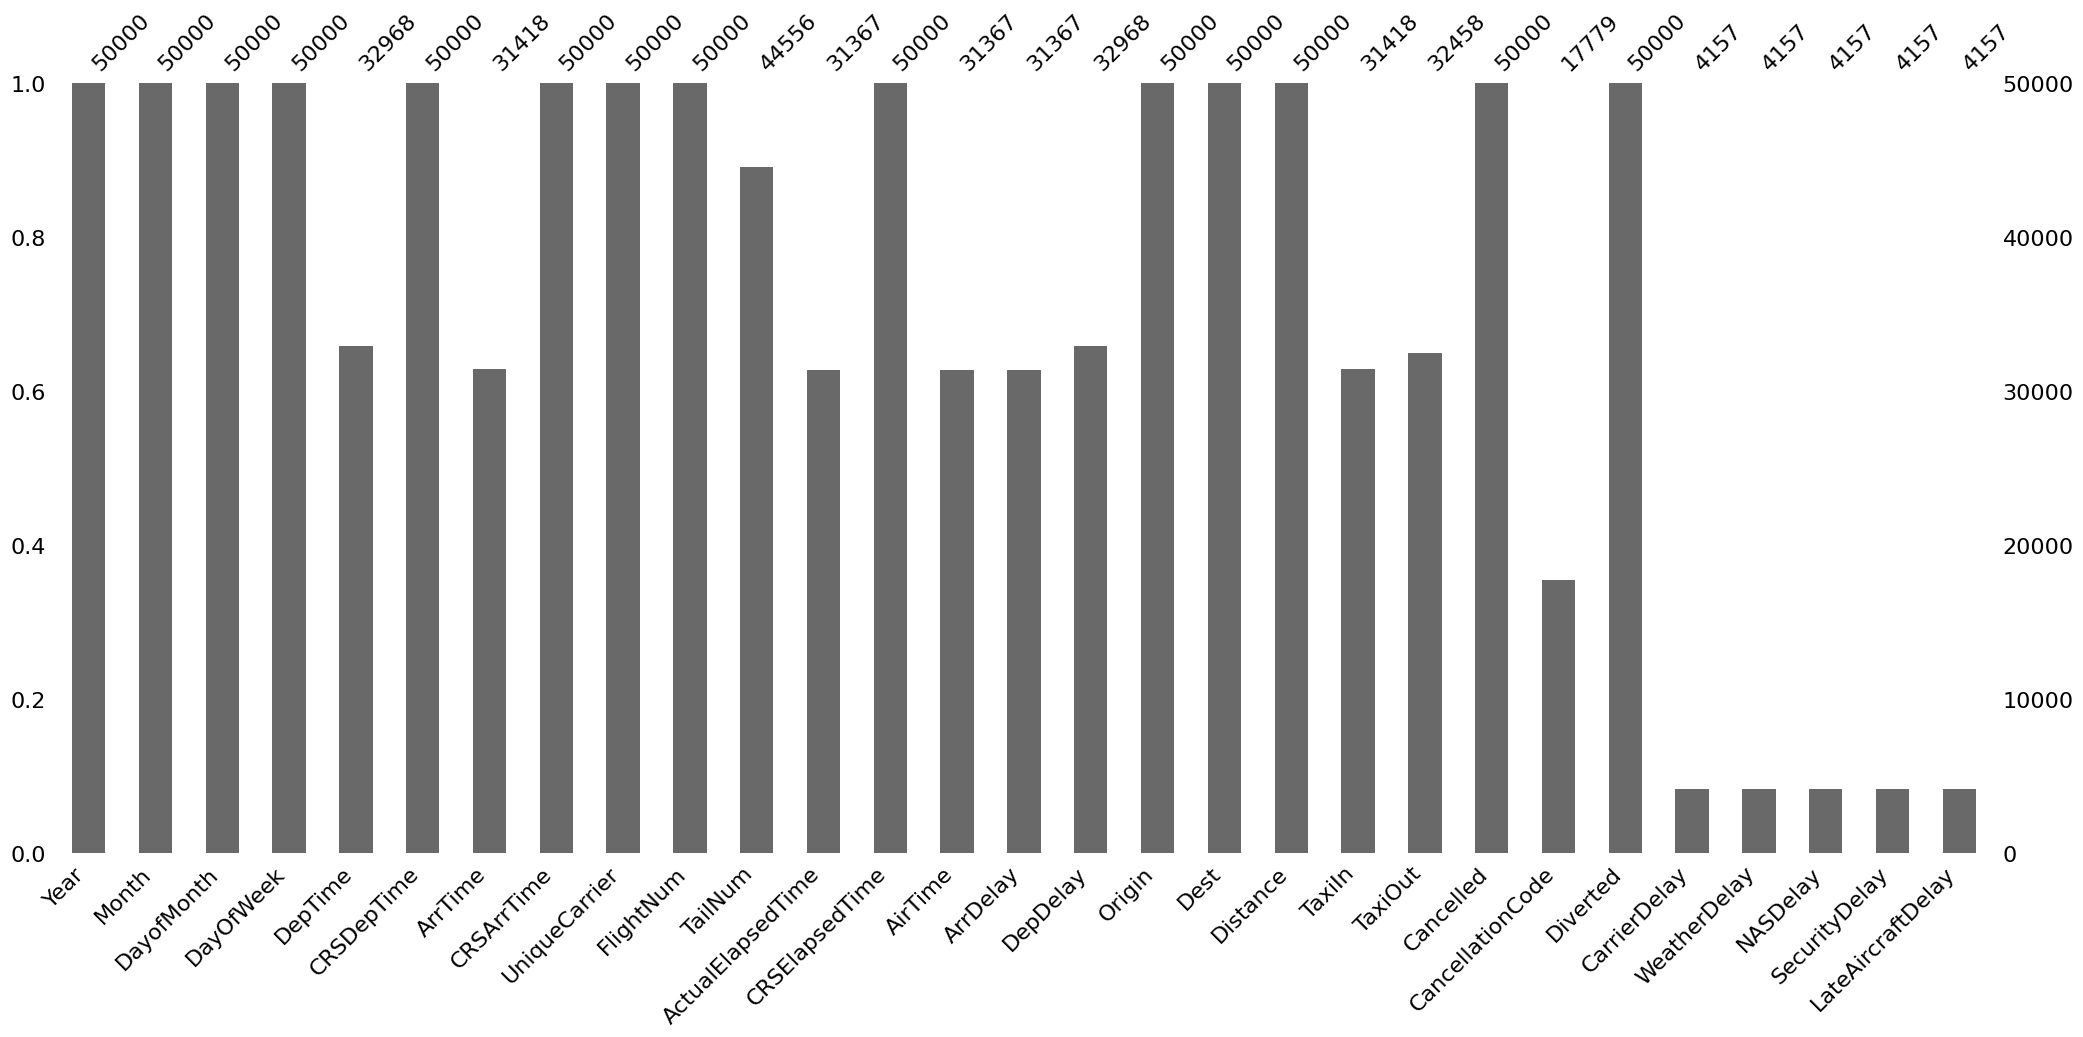

In [11]:
missingno.bar(df)
plt.show()

<Axes: >

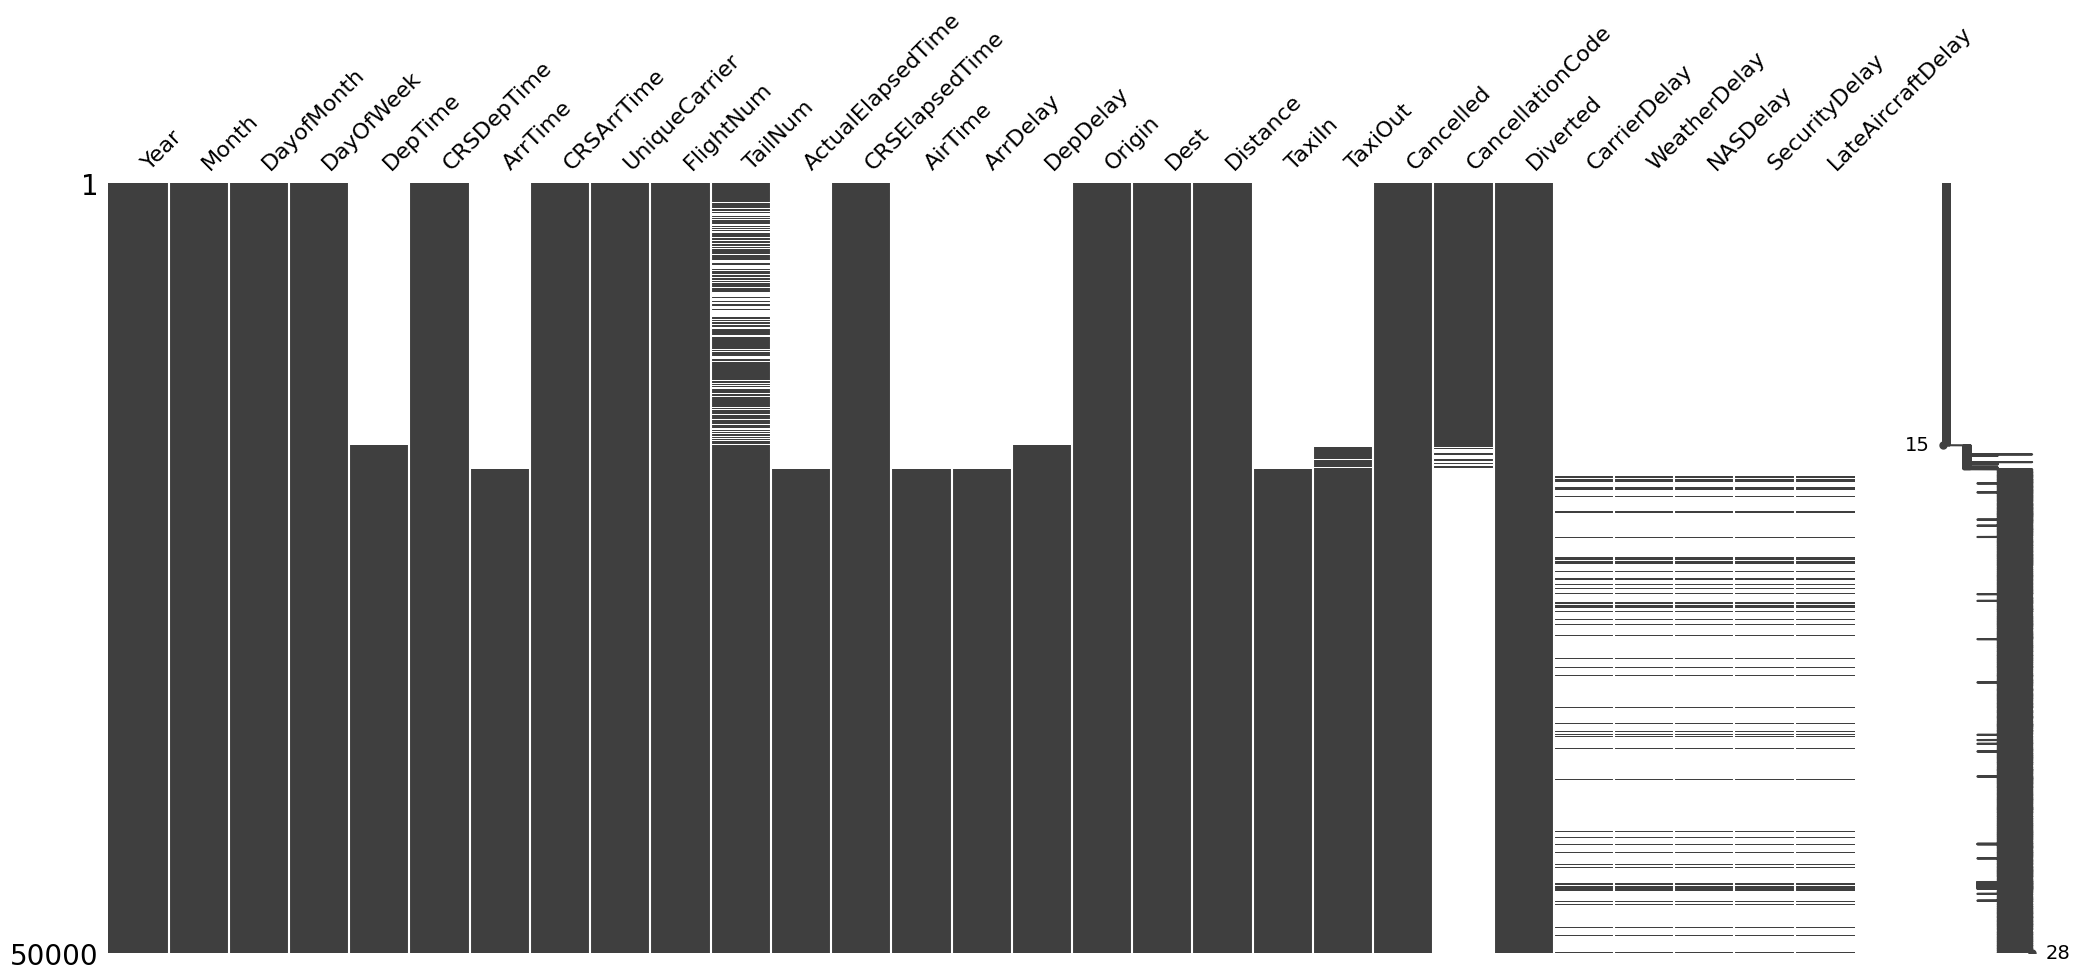

In [19]:
missingno.matrix(df)


From the missing values heatmap:

- Some features (like `Year`, `Month`, `DayofMonth`, `DayOfWeek`, `UniqueCarrier`, `Origin`, `Dest`, and `Distance`) **do not have any missing values**.
- Features related to departure and arrival times (`DepTime`, `ArrTime`, `ActualElapsedTime`, `AirTime`) have **some missing values**, likely due to canceled or diverted flights.
- `TailNum` has a **significant number of missing values**, suggesting some flights might not have an associated aircraft registration.
- `CancellationCode` has missing values likely for flights that were **not canceled** (expected behavior).
- Delay-related features (`CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, `LateAircraftDelay`) have **large missing value proportions**, which could be because delay reasons are only recorded for delayed flights.

---

# Visualizations for Data Exploration

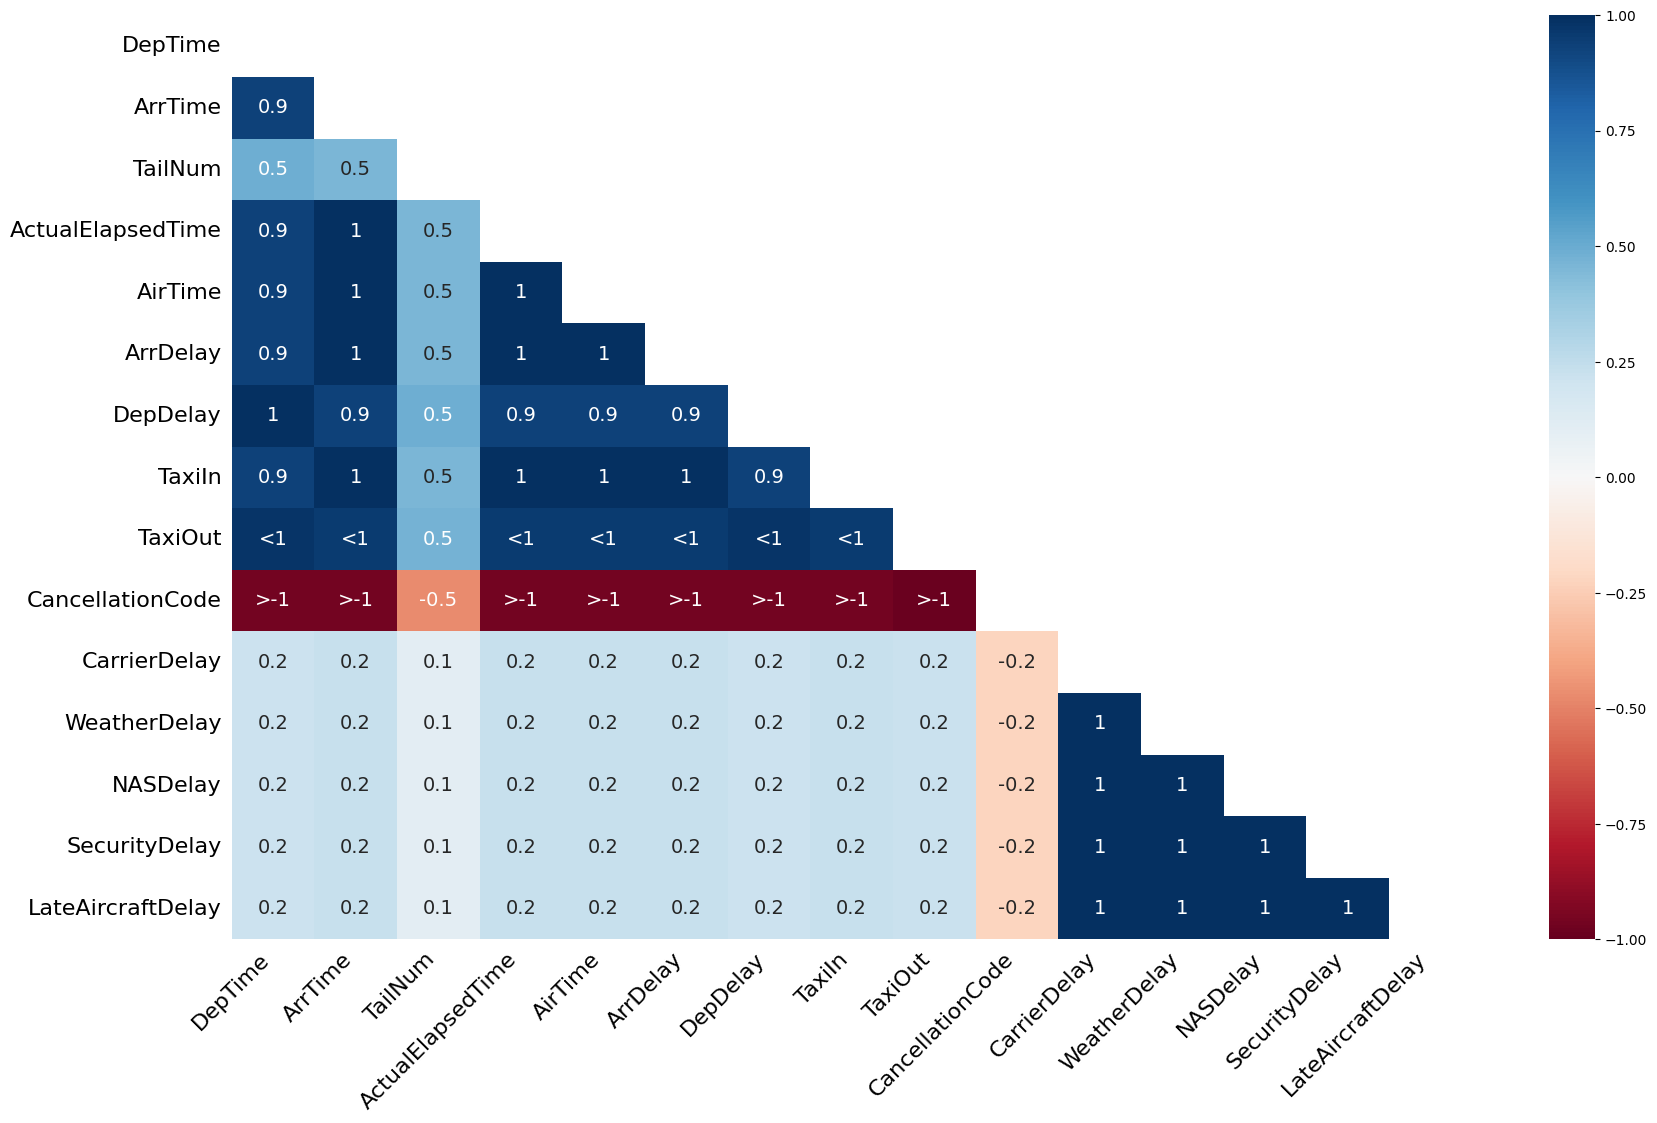

In [22]:
missingno.heatmap(df)
plt.show()

From the correlation heatmap, we can observe the following patterns:

1. **High Correlation Observed:**
   - `ActualElapsedTime`, `AirTime`, `ArrDelay`, `DepDelay`, and `TaxiIn` are highly correlated with each other.
   - `DepDelay` and `ArrDelay` show strong correlation (~0.9), indicating that late departures are strongly linked to late arrivals.
   - `TaxiIn` and `TaxiOut` show some level of correlation with flight delay times.
   
2. **Cancellation Code Behavior:**
   - The `CancellationCode` feature has **strong negative correlations** with multiple features, likely because canceled flights do not have arrival times, elapsed times, or delays recorded.
   - It is negatively correlated with `ActualElapsedTime`, `AirTime`, and `ArrDelay`, confirming that canceled flights lack these values.

3. **Delay Reasons:**
   - `CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, and `LateAircraftDelay` are **perfectly correlated (1.0) among themselves**, suggesting that they may not be mutually exclusive.
   - These features may be mutually dependent, and further investigation is needed to determine how they are recorded.

4. **Low Correlation Observed:**
   - `TailNum` has very little correlation with other numerical features, indicating that the aircraft identifier does not influence flight delays or performance directly.
   - `TaxiOut` has low correlation with `DepTime` and `ArrTime`, meaning taxiing time is relatively independent of these factors.

---

In [36]:
# Count how many times each unique combination of delay reasons occurs
delay_reasons = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
delay_combinations = df[delay_reasons].dropna().astype(bool).astype(int)
print("Unique Combinations of Delay Reasons:")
print(delay_combinations.drop_duplicates())

Unique Combinations of Delay Reasons:
       CarrierDelay  WeatherDelay  NASDelay  SecurityDelay  LateAircraftDelay
1                 0             0         0              0                  0
17623             0             0         1              0                  0
18123             1             0         0              0                  1
18601             1             0         0              0                  0
18606             1             0         1              0                  1
18624             0             0         1              0                  1
18625             1             0         1              0                  0
18635             0             0         0              0                  1
18829             1             1         0              0                  0
18919             1             1         1              0                  0
19110             0             1         1              0                  0
19250             0       

- The table of unique combinations shows that multiple delay reasons can occur simultaneously for a single flight.
- Some flights have **only one type of delay** (e.g., `CarrierDelay` or `NASDelay`), while others have multiple delay reasons.
- This suggests that delay causes **are not mutually exclusive**, meaning a flight can be delayed due to both weather and carrier issues, for example.

In [31]:
# Count occurrences of flights with multiple delay reasons
df['Total_Delay_Reasons'] = df[delay_reasons].sum(axis=1)

print("Counts of Flights by Number of Delay Reasons Recorded:")
print(df['Total_Delay_Reasons'].value_counts())


Counts of Flights by Number of Delay Reasons Recorded:
Total_Delay_Reasons
0.0      45843
15.0       250
17.0       221
18.0       215
16.0       211
         ...  
208.0        1
195.0        1
121.0        1
217.0        1
224.0        1
Name: count, Length: 215, dtype: int64


- The count of flights with different numbers of delay reasons shows:
  - A large proportion of flights (45,843) have zero recorded delay reasons (because of missing data).
  - Some flights have multiple delay reasons recorded, with values going up to 250 in rare cases.
  - This suggests that certain flights accumulate many recorded delay causes, which may need further investigation for data accuracy.

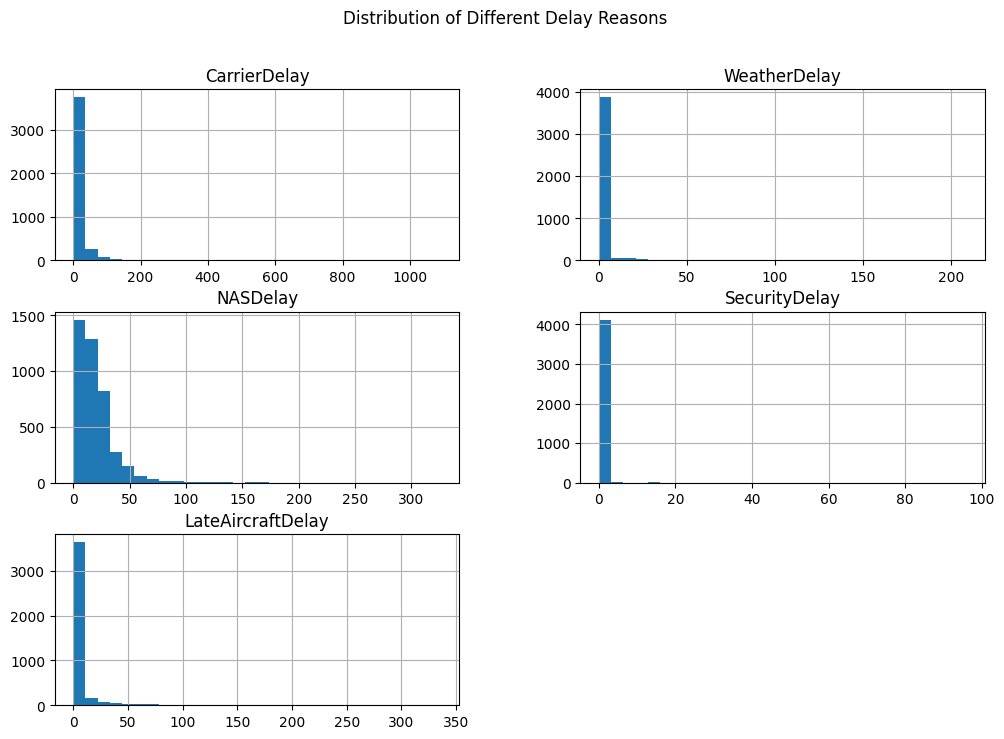

In [29]:
# Plot histograms of each delay reason
df[delay_reasons].hist(figsize=(12,8), bins=30, layout=(3,2))
plt.suptitle("Distribution of Different Delay Reasons")
plt.show()


- **CarrierDelay, WeatherDelay, NASDelay, SecurityDelay, and LateAircraftDelay** all show **skewed distributions** with most values being small but a few extreme cases.
- Most delays are short, but a few flights experience extreme delays.
- `SecurityDelay` is the least frequent delay cause compared to others.

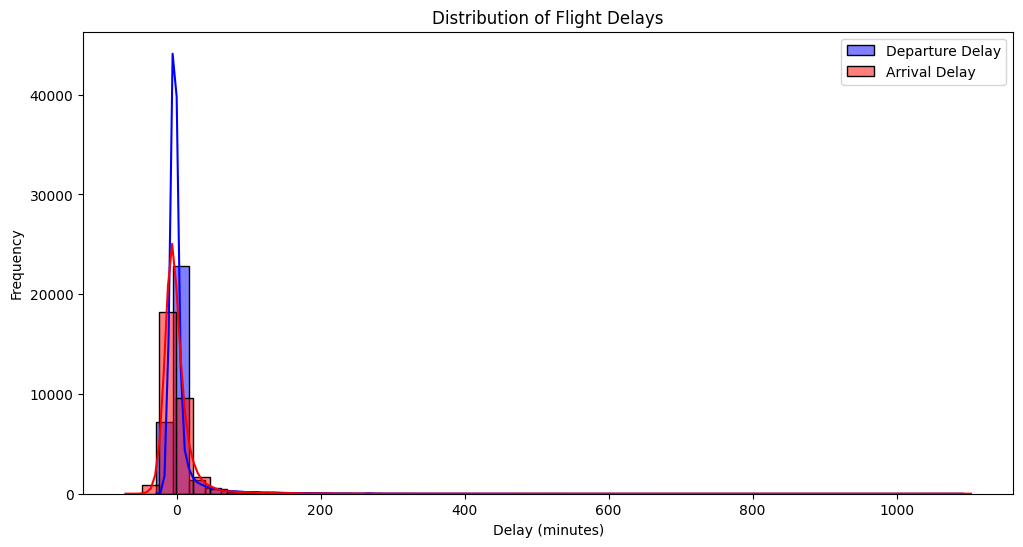

In [12]:
plt.figure(figsize=(12,6))

sns.histplot(df['DepDelay'].dropna(), bins=50, kde=True, color='blue', label="Departure Delay")

sns.histplot(df['ArrDelay'].dropna(), bins=50, kde=True, color='red', label="Arrival Delay")

plt.title("Distribution of Flight Delays")
plt.xlabel("Delay (minutes)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

Most departure and arrival delays are clustered around 0-50 minutes, with a few extreme delays reaching over 600 minutes.

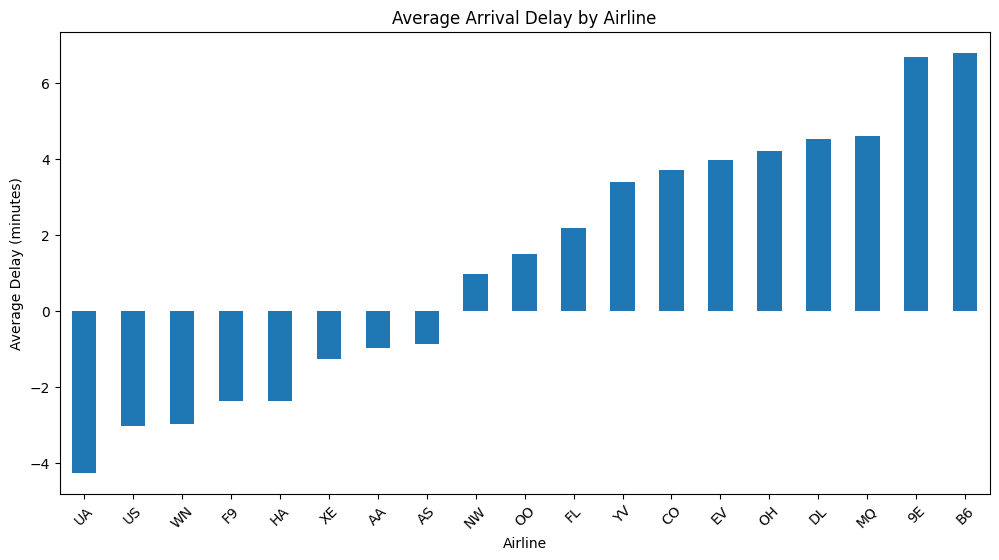

In [24]:
plt.figure(figsize=(12,6))

carrier_delays = df.groupby('UniqueCarrier')['ArrDelay'].mean().sort_values()
carrier_delays.plot(kind='bar')

plt.title("Average Arrival Delay by Airline")
plt.ylabel("Average Delay (minutes)")
plt.xlabel("Airline")
plt.xticks(rotation=45)
plt.show()


Some airlines experienced negative average delays (early arrivals), while others had consistent positive delays.
Airlines 9E and B6 had the worst average delays, while UA had the best performance with early arrivals.

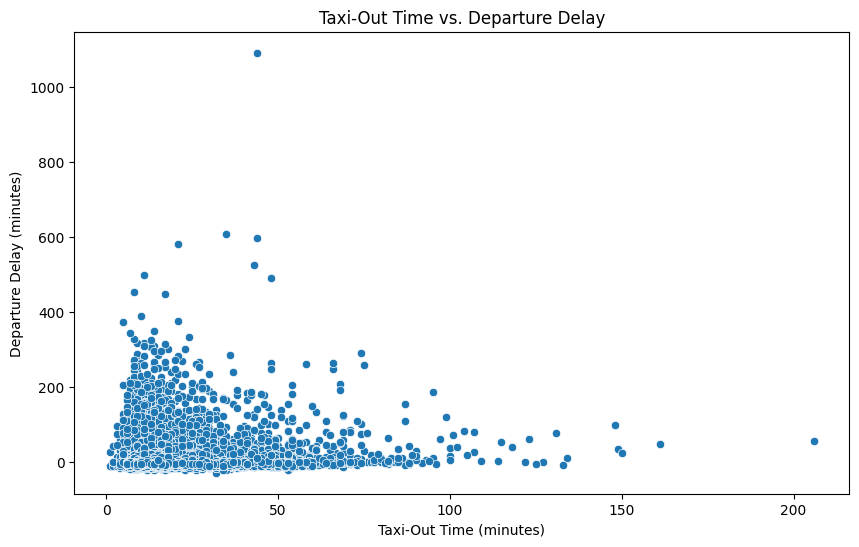

In [39]:
plt.figure(figsize=(10,6))

sns.scatterplot(x=df['TaxiOut'], y=df['DepDelay'])

plt.title("Taxi-Out Time vs. Departure Delay")
plt.xlabel("Taxi-Out Time (minutes)")
plt.ylabel("Departure Delay (minutes)")
plt.show()

There is no strong linear relationship between taxi-out time and departure delay, but flights with very long taxi-out times (50+ minutes) often have high delays.
Most flights have a taxi-out time under 30 minutes, but outliers exist beyond 100 minutes.

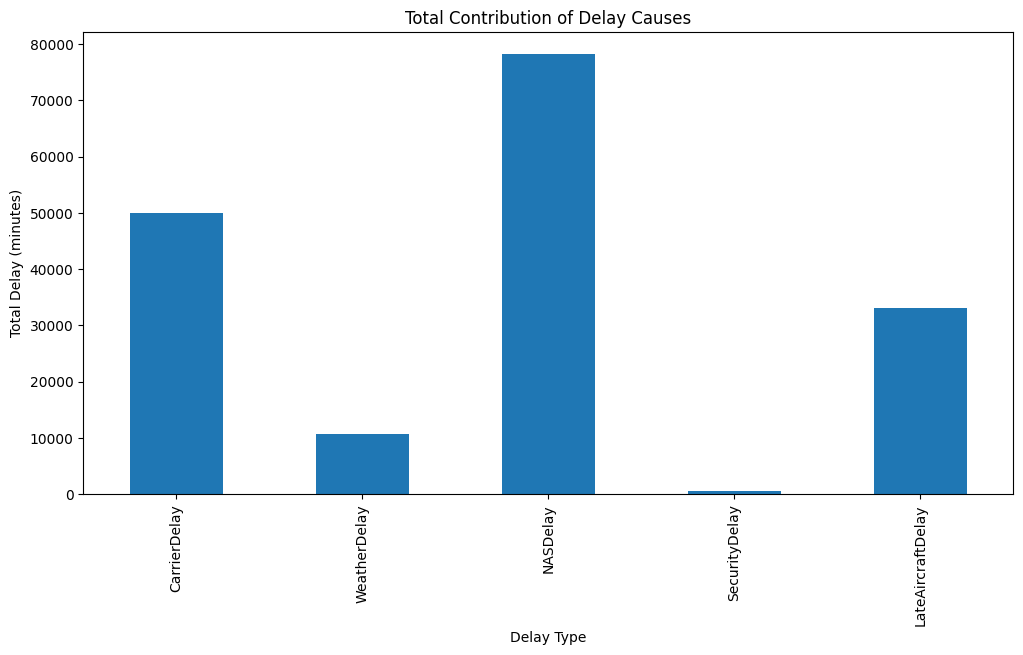

In [14]:
delay_reasons = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']

df[delay_reasons].sum().plot(kind='bar', stacked=True, figsize=(12,6))

plt.title("Total Contribution of Delay Causes")
plt.ylabel("Total Delay (minutes)")
plt.xlabel("Delay Type")
plt.show()


NAS delays were the largest contributor, followed by Carrier and Late Aircraft delays.
Weather and Security delays had a minor impact compared to other causes.

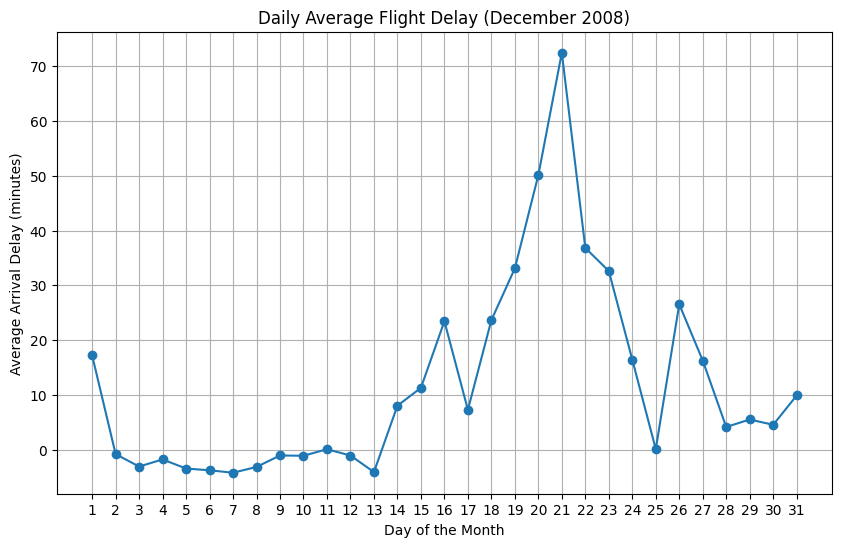

In [41]:
plt.figure(figsize=(10,6))

df.groupby('DayofMonth')['ArrDelay'].mean().plot(marker='o', linestyle='-')

plt.title("Daily Average Flight Delay (December 2008)")
plt.xlabel("Day of the Month")
plt.ylabel("Average Arrival Delay (minutes)")
plt.xticks(range(1,32))
plt.grid()
plt.show()


There was a sharp increase in delays around December 18-21, peaking at over 70 minutes on the 21st.
Delays decreased after December 22, suggesting possible disruptions around holiday travel peaks.


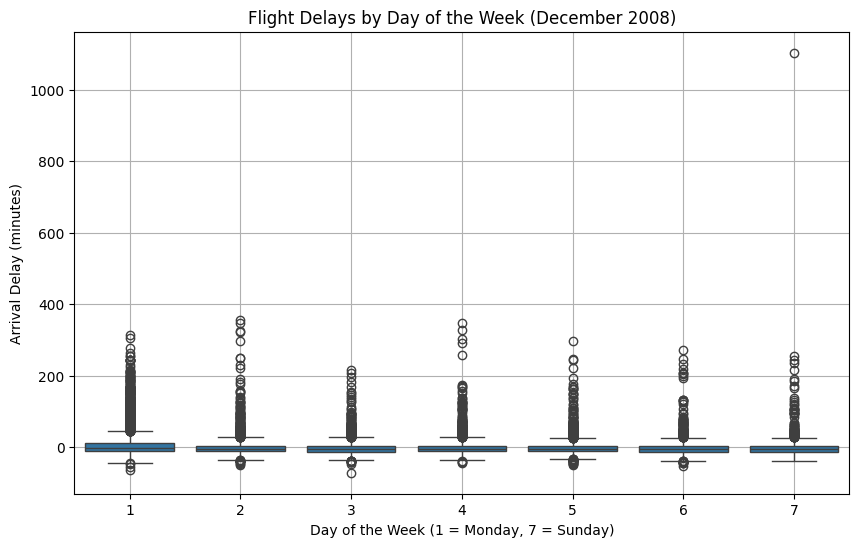

In [42]:
plt.figure(figsize=(10,6))

sns.boxplot(x='DayOfWeek', y='ArrDelay', data=df)

plt.title("Flight Delays by Day of the Week (December 2008)")
plt.xlabel("Day of the Week (1 = Monday, 7 = Sunday)")
plt.ylabel("Arrival Delay (minutes)")
plt.grid()
plt.show()


The median arrival delay is fairly consistent across all days of the week, but there are many extreme outliers (delays over 400+ minutes).
Sundays (Day 7) appear to have the largest extreme delay, suggesting possible disruptions on that day.

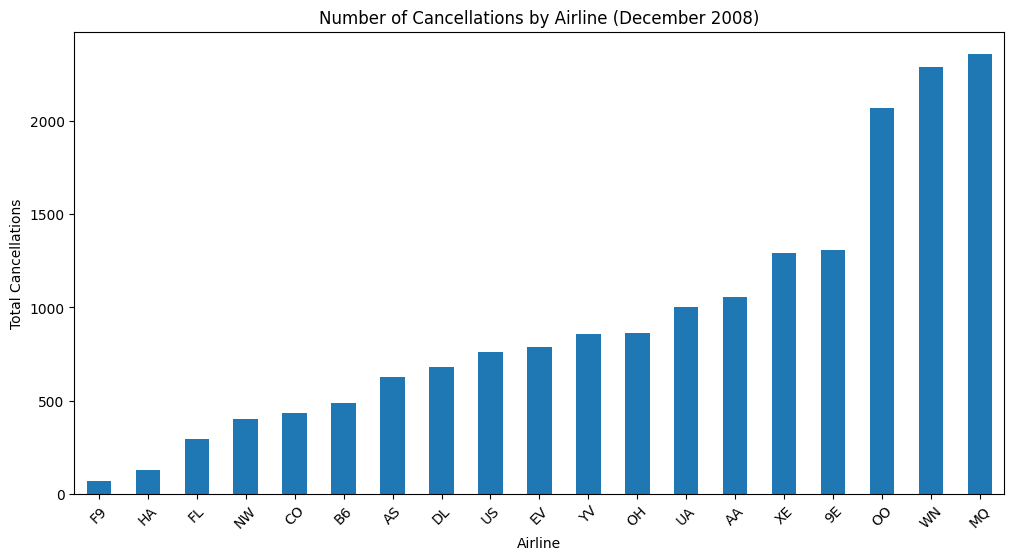

In [15]:
plt.figure(figsize=(12,6))

df.groupby('UniqueCarrier')['Cancelled'].sum().sort_values().plot(kind='bar')

plt.title("Number of Cancellations by Airline (December 2008)")
plt.ylabel("Total Cancellations")
plt.xlabel("Airline")
plt.xticks(rotation=45)
plt.show()


Airlines MQ, WN, and OO had the highest number of cancellations, while F9 and HA had the least.
This indicates significant differences in airline reliability during this period.

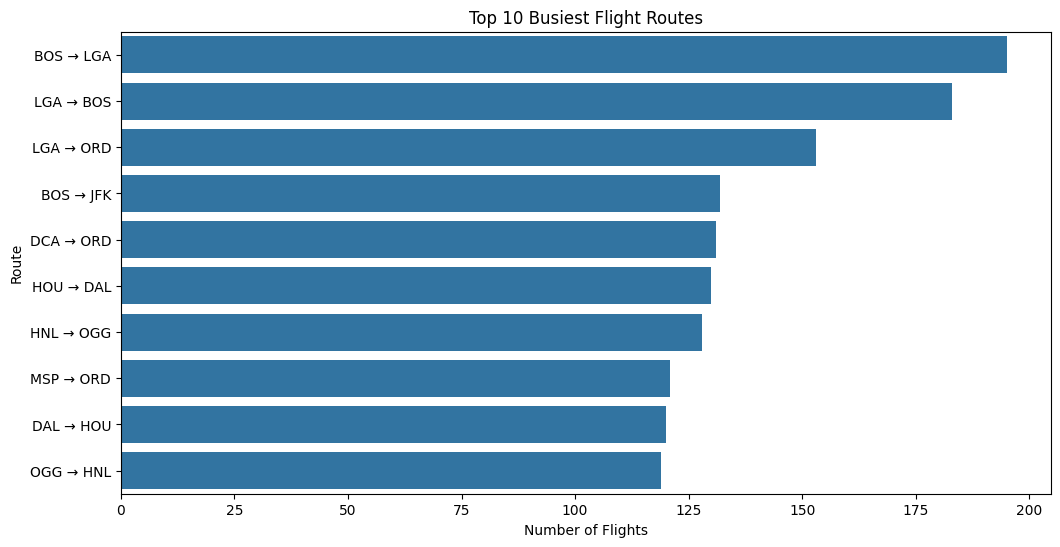

In [18]:
df['Route'] = df['Origin'] + " → " + df['Dest']

top_routes = df['Route'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_routes.values, y=top_routes.index)

plt.title("Top 10 Busiest Flight Routes")
plt.xlabel("Number of Flights")
plt.ylabel("Route")
plt.show()

The BOS ↔ LGA (Boston to LaGuardia) route is the busiest, followed by LGA ↔ ORD (LaGuardia to Chicago O’Hare).
These routes likely have high demand due to major city connections.

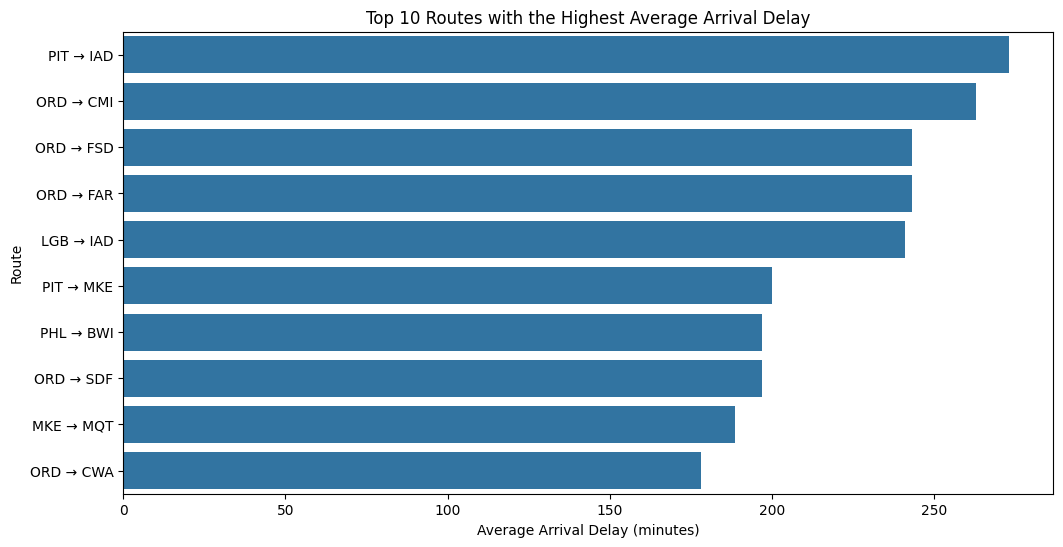

In [20]:
plt.figure(figsize=(12,6))

top_delayed_routes = df.groupby('Route')['ArrDelay'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_delayed_routes.values, y=top_delayed_routes.index)

plt.title("Top 10 Routes with the Highest Average Arrival Delay")
plt.xlabel("Average Arrival Delay (minutes)")
plt.ylabel("Route")
plt.show()


PIT → IAD (Pittsburgh to Dulles) has the longest average arrival delay, exceeding 250 minutes.
Several ORD (Chicago O'Hare) routes also experience severe delays, indicating possible congestion or weather issues.

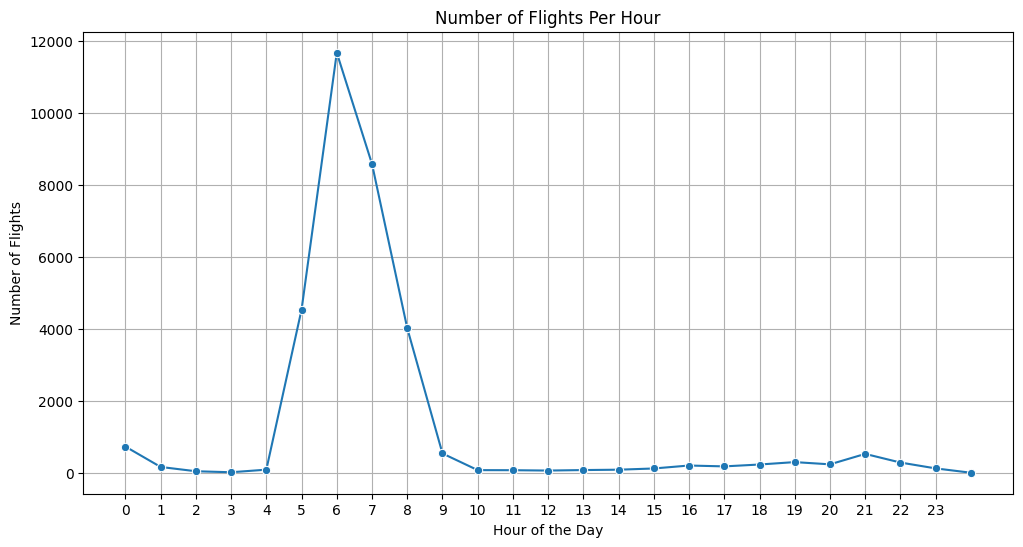

In [21]:
plt.figure(figsize=(12,6))

df['DepHour'] = df['DepTime'] // 100  # Extract departure hour
flights_per_hour = df['DepHour'].value_counts().sort_index()

sns.lineplot(x=flights_per_hour.index, y=flights_per_hour.values, marker="o")
plt.title("Number of Flights Per Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Flights")
plt.xticks(range(24))
plt.grid()
plt.show()


Flights peak between 6-8 AM, with a sharp drop afterward, followed by minimal activity during midday.
This suggests that early morning is the busiest travel period, possibly due to business travel and airline scheduling efficiency.

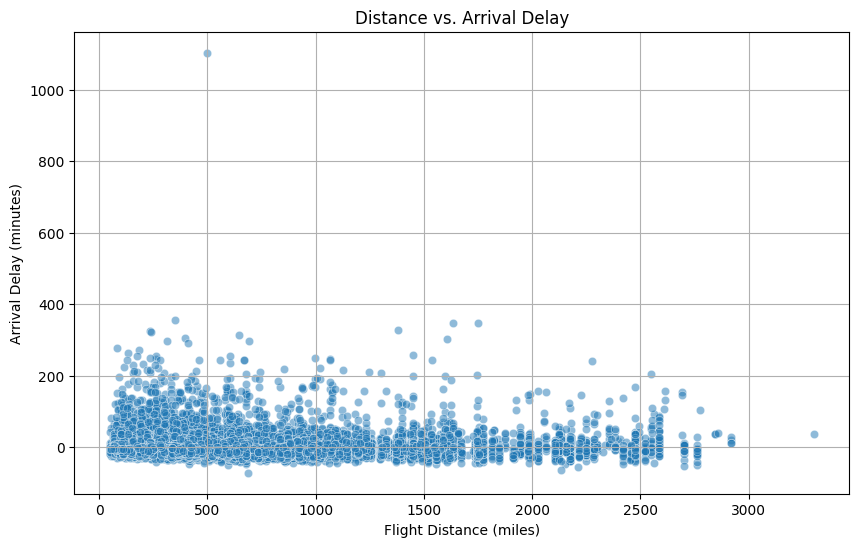

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(x=df['Distance'], y=df['ArrDelay'], alpha=0.5)
plt.title("Distance vs. Arrival Delay")
plt.xlabel("Flight Distance (miles)")
plt.ylabel("Arrival Delay (minutes)")
plt.grid()
plt.show()


No strong correlation between flight distance and arrival delay, meaning both short and long-haul flights experience similar delay patterns.
Some extreme delays appear across different distances, indicating external factors like airport congestion or weather disruptions.